In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import koreanize_matplotlib

In [3]:
data = pd.read_csv("./data/wine_train.csv")
data

,와인_종류,알코올_도수,사과산_함량,재_함량,재의_알칼리도,마그네슘_함량,총_페놀_함량,플라보노이드_함량,비플라보노이드_페놀_함량,프로안토시아닌_함량,색_강도,색조,희석_와인의_투과율_OD280_OD315,프롤린_함량
0,1,13.76,1.53,2.70,19.5,132,2.95,2.74,0.50,1.35,5.40,1.25,3.00,1235
1,2,12.67,0.98,2.24,18.0,99,2.20,1.94,0.30,1.46,2.62,1.23,3.16,450
2,1,13.58,1.66,2.36,19.1,106,2.86,3.19,0.22,1.95,6.90,1.09,2.88,1515
3,2,13.86,1.51,2.67,25.0,86,2.95,2.86,0.21,1.87,3.38,1.36,3.16,410
4,1,13.05,2.05,3.22,25.0,124,2.63,2.68,0.47,1.92,3.58,1.13,3.20,830
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
101,2,12.43,1.53,2.29,21.5,86,2.74,3.15,0.39,1.77,3.94,0.69,2.84,352
102,3,12.20,3.03,2.32,19.0,96,1.25,0.49,0.40,0.73,5.50,0.66,1.83,510
103,1,13.51,1.80,2.65,19.0,110,2.35,2.53,0.29,1.54,4.20,1.10,2.87,1095
104,2,12.70,3.87,2.40,23.0,101,2.83,2.55,0.43,1.95,2.57,1.19,3.13,463


In [5]:
data['와인_종류'].value_counts()

와인_종류
2    42
1    35
3    29
Name: count, dtype: int64

In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 106 entries, 0 to 105
Data columns (total 14 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   와인_종류                   106 non-null    int64  
 1   알코올_도수                  106 non-null    float64
 2   사과산_함량                  106 non-null    float64
 3   재_함량                    106 non-null    float64
 4   재의_알칼리도                 106 non-null    float64
 5   마그네슘_함량                 106 non-null    int64  
 6   총_페놀_함량                 106 non-null    float64
 7   플라보노이드_함량               106 non-null    float64
 8   비플라보노이드_페놀_함량           106 non-null    float64
 9   프로안토시아닌_함량              106 non-null    float64
 10  색_강도                    106 non-null    float64
 11  색조                      106 non-null    float64
 12  희석_와인의_투과율_OD280_OD315  106 non-null    float64
 13  프롤린_함량                  106 non-null    int64  
dtypes: float64(11), int64(3)
memory usage: 11.

<Axes: >

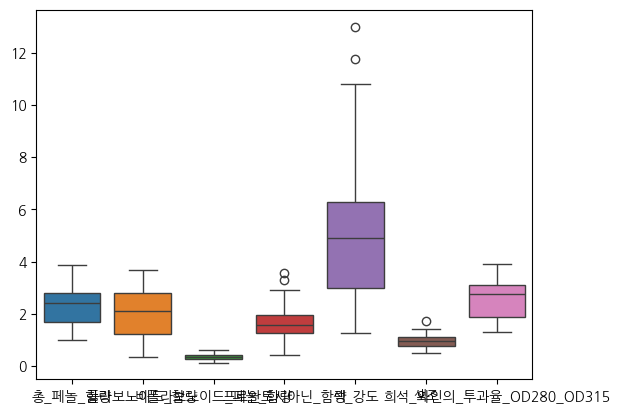

In [12]:
sns.boxplot(data.iloc[:,6:-1])

In [13]:
X = data.drop('와인_종류', axis=1)
y = data['와인_종류']

In [14]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, stratify=y, random_state=42)

In [15]:
from sklearn.preprocessing import MinMaxScaler

In [16]:
mms = MinMaxScaler()
X_train_temp = mms.fit_transform(X_train)
X_test_temp = mms.transform(X_test)
mms_X_train = pd.DataFrame(X_train_temp, columns=X_train.columns, index=X_train.index)
mms_X_test = pd.DataFrame(X_test_temp, columns=X_test.columns, index=X_test.index)

# mms 변수에 있는 MinMaxScaler 가중치 저장
# joblib
* joblib.dump(경로, 파일명)
* joblib.load(경로, 파일명)

In [28]:
import joblib

In [29]:
joblib.dump(mms, "./model/MinMax_info.joblib")

['./model/MinMax_info.joblib']

In [17]:
mms_X_train

,알코올_도수,사과산_함량,재_함량,재의_알칼리도,마그네슘_함량,총_페놀_함량,플라보노이드_함량,비플라보노이드_페놀_함량,프로안토시아닌_함량,색_강도,색조,희석_와인의_투과율_OD280_OD315,프롤린_함량
79,0.700000,0.479508,0.634409,0.573171,0.294872,0.223077,0.021875,0.74,0.132867,0.392491,0.390244,0.189189,0.324980
54,0.297368,0.141393,0.510753,0.743902,0.076923,0.203846,0.375000,0.60,0.398601,0.099829,0.691057,0.359073,0.175424
98,0.755263,0.155738,0.408602,0.329268,0.217949,0.711538,0.906250,0.16,0.601399,0.411263,0.349593,0.772201,0.571544
20,0.207895,0.163934,0.279570,0.542683,0.025641,0.480769,0.359375,0.48,0.349650,0.066553,0.373984,0.428571,0.110752
92,0.823684,0.325820,0.602151,0.573171,0.089744,0.165385,0.065625,0.62,0.286713,0.718430,0.113821,0.146718,0.308812
...,...,...,...,...,...,...,...,...,...,...,...,...,...
43,0.744737,0.088115,0.489247,0.329268,0.179487,0.665385,0.831250,0.18,0.500000,0.506826,0.430894,0.857143,0.620049
16,0.413158,0.086066,0.290323,0.481707,0.051282,0.076923,0.271875,0.32,0.325175,0.099829,0.455285,0.555985,0.229588
59,0.484211,0.756148,0.602151,0.664634,0.025641,0.173077,0.050000,0.68,0.153846,0.543515,0.048780,0.204633,0.280517
37,0.000000,0.120902,0.451613,0.664634,0.012821,0.465385,0.525000,0.78,0.555944,0.052901,1.000000,0.594595,0.104285


In [18]:
mms_X_test

,알코올_도수,사과산_함량,재_함량,재의_알칼리도,마그네슘_함량,총_페놀_함량,플라보노이드_함량,비플라보노이드_페놀_함량,프로안토시아닌_함량,색_강도,색조,희석_와인의_투과율_OD280_OD315,프롤린_함량
61,0.486842,0.424180,0.559140,0.573171,0.256410,0.019231,0.228125,0.22,0.143357,0.351536,0.211382,0.034749,0.203719
63,0.331579,0.141393,0.456989,0.597561,0.243590,-0.057692,0.165625,0.48,0.363636,0.151024,0.346341,0.189189,0.478577
3,0.744737,0.120902,0.704301,0.878049,0.025641,0.653846,0.740625,0.16,0.506993,0.179181,0.715447,0.706564,0.106710
40,0.331579,0.461066,0.456989,0.451220,0.051282,0.615385,0.781250,0.64,0.835664,0.087031,0.764228,0.579151,0.103476
97,0.750000,0.844262,0.467742,0.573171,-0.051282,-0.103846,-0.046875,0.54,0.090909,0.308874,0.081301,0.000000,0.110752
81,0.439474,0.538934,0.537634,0.664634,0.282051,0.173077,0.221875,0.08,0.146853,0.317406,0.243902,-0.015444,0.260307
78,0.650000,0.450820,0.677419,0.817073,0.500000,0.057692,0.337500,0.18,0.290210,0.624573,0.089431,-0.011583,0.179466
95,0.276316,0.186475,0.516129,0.481707,-0.038462,0.134615,0.315625,0.78,0.426573,0.095563,0.487805,0.362934,0.163298
65,0.613158,0.336066,0.532258,0.573171,0.064103,0.057692,0.003125,0.48,0.076923,0.368601,0.178862,0.440154,0.405821
57,0.721053,0.200820,0.709677,0.396341,0.397436,0.673077,0.718750,0.52,0.440559,0.428328,0.528455,0.617761,0.886823


In [20]:
y_train.value_counts()

와인_종류
2    29
1    25
3    20
Name: count, dtype: int64

In [21]:
y_train = pd.get_dummies(y_train)
y_train

,1,2,3
79,False,False,True
54,False,True,False
98,True,False,False
20,False,True,False
92,False,False,True
...,...,...,...
43,True,False,False
16,False,True,False
59,False,False,True
37,False,True,False


In [22]:
y_test = pd.get_dummies(y_test)
y_test

,1,2,3
61,False,False,True
63,False,True,False
3,False,True,False
40,False,True,False
97,False,False,True
81,False,False,True
78,False,False,True
95,False,True,False
65,False,False,True
57,True,False,False


In [23]:
from keras.models import Sequential
from keras.layers import Input, Dense
from keras.callbacks import EarlyStopping, ModelCheckpoint

In [25]:
model = Sequential()
model.add(Input(shape=(mms_X_train.shape[1],)))
model.add(Dense(64, activation='relu'))
model.add(Dense(32, activation='relu'))
model.add(Dense(16, activation='relu'))
model.add(Dense(y_train.shape[1], activation='softmax'))
model.summary()

I0000 00:00:1747294841.099267  202177 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 2972 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3060 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.6


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,555 (13.89 KB)

 Trainable params: 3,555 (13.89 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/1000


I0000 00:00:1747295285.950809  224556 service.cc:152] XLA service 0x7f7f90004b00 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1747295285.950871  224556 service.cc:160]   StreamExecutor device (0): NVIDIA GeForce RTX 3060 Laptop GPU, Compute Capability 8.6
2025-05-15 16:48:05.978234: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1747295286.134576  224556 cuda_dnn.cc:529] Loaded cuDNN version 90300


1/5 ━━━━━━━━━━━━━━━━━━━━ 8s 2s/step - accuracy: 0.6250 - loss: 1.0779

I0000 00:00:1747295287.379094  224556 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


5/5 ━━━━━━━━━━━━━━━━━━━━ 4s 455ms/step - accuracy: 0.5482 - loss: 1.0773 - val_accuracy: 0.5625 - val_loss: 1.0536
Epoch 2/1000
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.6770 - loss: 1.0346 - val_accuracy: 0.5938 - val_loss: 1.0266
Epoch 3/1000
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.6190 - loss: 1.0194 - val_accuracy: 0.6562 - val_loss: 1.0007
Epoch 4/1000
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.6398 - loss: 0.9886 - val_accuracy: 0.6250 - val_loss: 0.9743
Epoch 5/1000
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.6754 - loss: 0.9382 - val_accuracy: 0.6250 - val_loss: 0.9449
Epoch 6/1000
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.6563 - loss: 0.9274 - val_accuracy: 0.6250 - val_loss: 0.9133
Epoch 7/1000
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.6251 - loss: 0.9082 - val_accuracy: 0.6250 - val_loss: 0.8802
Epoch 8/1000
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.6650 - loss: 0.8513 - val_accuracy: 0.6250 - val_loss: 0.8

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 1.0000 - loss: 0.0226 - val_accuracy: 0.9688 - val_loss: 0.1355
Epoch 52/1000
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 1.0000 - loss: 0.0233 - val_accuracy: 0.9688 - val_loss: 0.1321
Epoch 53/1000
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 1.0000 - loss: 0.0225 - val_accuracy: 0.9688 - val_loss: 0.1297
Epoch 54/1000
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 1.0000 - loss: 0.0215 - val_accuracy: 0.9688 - val_loss: 0.1278
Epoch 55/1000
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 1.0000 - loss: 0.0192 - val_accuracy: 0.9688 - val_loss: 0.1203
Epoch 56/1000
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 1.0000 - loss: 0.0190 - val_accuracy: 0.9688 - val_loss: 0.1259
Epoch 57/1000
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 1.0000 - loss: 0.0180 - val_accuracy: 0.9688 - val_loss: 0.1285
Epoch 58/1000
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 1.0000 - loss: 0.0190 - val_accuracy: 0.9688 - val_los

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 1.0000 - loss: 0.0043 - val_accuracy: 0.9688 - val_loss: 0.1342
Epoch 102/1000
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 1.0000 - loss: 0.0033 - val_accuracy: 0.9688 - val_loss: 0.1357
Epoch 103/1000
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 1.0000 - loss: 0.0039 - val_accuracy: 0.9688 - val_loss: 0.1355
Epoch 104/1000
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 1.0000 - loss: 0.0034 - val_accuracy: 0.9688 - val_loss: 0.1358
Epoch 105/1000
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 1.0000 - loss: 0.0025 - val_accuracy: 0.9688 - val_loss: 0.1355
Epoch 106/1000
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 1.0000 - loss: 0.0033 - val_accuracy: 0.9688 - val_loss: 0.1360
Epoch 107/1000
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 1.0000 - loss: 0.0027 - val_accuracy: 0.9688 - val_loss: 0.1368
Epoch 108/1000
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 1.0000 - loss: 0.0028 - val_accuracy: 0.9688 - 

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 1.0000 - loss: 0.0013 - val_accuracy: 0.9688 - val_loss: 0.1452
Epoch 152/1000
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 1.0000 - loss: 0.0014 - val_accuracy: 0.9688 - val_loss: 0.1453
Epoch 153/1000
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 1.0000 - loss: 0.0011 - val_accuracy: 0.9688 - val_loss: 0.1453
Epoch 154/1000
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 1.0000 - loss: 0.0012 - val_accuracy: 0.9688 - val_loss: 0.1455
Epoch 155/1000
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 1.0000 - loss: 0.0012 - val_accuracy: 0.9688 - val_loss: 0.1479
Epoch 156/1000
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 1.0000 - loss: 0.0011 - val_accuracy: 0.9688 - val_loss: 0.1488
Epoch 157/1000
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 1.0000 - loss: 9.3404e-04 - val_accuracy: 0.9688 - val_loss: 0.1465
Epoch 158/1000
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 1.0000 - loss: 8.9598e-04 - val_accuracy: 0

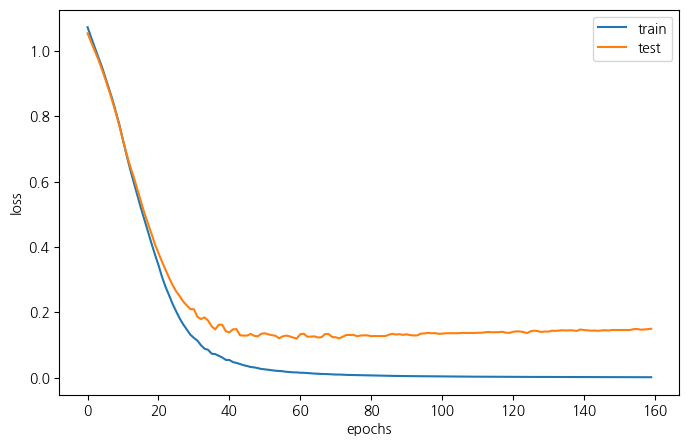

In [27]:
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
early_stop = EarlyStopping(patience=100)
# file_path = "./model/wine_{val_loss:.4f}_{epoch:04d}.keras"
file_path = "./model/wine_best_model.keras"
model_save = ModelCheckpoint(filepath=file_path, save_best_only=True)
history = model.fit(mms_X_train, y_train,
                   epochs=1000,
                   batch_size=16,
                   validation_data=(mms_X_test, y_test),
                   callbacks=[early_stop, model_save])
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.xlabel("epochs")
plt.ylabel("loss")
plt.legend(['train', 'test'])
plt.show()

# 머신러닝 스케일러와 모델 저장하기

In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import koreanize_matplotlib

In [31]:
data = pd.read_csv("./data/wine_train.csv")
data

,와인_종류,알코올_도수,사과산_함량,재_함량,재의_알칼리도,마그네슘_함량,총_페놀_함량,플라보노이드_함량,비플라보노이드_페놀_함량,프로안토시아닌_함량,색_강도,색조,희석_와인의_투과율_OD280_OD315,프롤린_함량
0,1,13.76,1.53,2.70,19.5,132,2.95,2.74,0.50,1.35,5.40,1.25,3.00,1235
1,2,12.67,0.98,2.24,18.0,99,2.20,1.94,0.30,1.46,2.62,1.23,3.16,450
2,1,13.58,1.66,2.36,19.1,106,2.86,3.19,0.22,1.95,6.90,1.09,2.88,1515
3,2,13.86,1.51,2.67,25.0,86,2.95,2.86,0.21,1.87,3.38,1.36,3.16,410
4,1,13.05,2.05,3.22,25.0,124,2.63,2.68,0.47,1.92,3.58,1.13,3.20,830
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
101,2,12.43,1.53,2.29,21.5,86,2.74,3.15,0.39,1.77,3.94,0.69,2.84,352
102,3,12.20,3.03,2.32,19.0,96,1.25,0.49,0.40,0.73,5.50,0.66,1.83,510
103,1,13.51,1.80,2.65,19.0,110,2.35,2.53,0.29,1.54,4.20,1.10,2.87,1095
104,2,12.70,3.87,2.40,23.0,101,2.83,2.55,0.43,1.95,2.57,1.19,3.13,463


In [32]:
data['와인_종류'].value_counts()

와인_종류
2    42
1    35
3    29
Name: count, dtype: int64

In [33]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 106 entries, 0 to 105
Data columns (total 14 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   와인_종류                   106 non-null    int64  
 1   알코올_도수                  106 non-null    float64
 2   사과산_함량                  106 non-null    float64
 3   재_함량                    106 non-null    float64
 4   재의_알칼리도                 106 non-null    float64
 5   마그네슘_함량                 106 non-null    int64  
 6   총_페놀_함량                 106 non-null    float64
 7   플라보노이드_함량               106 non-null    float64
 8   비플라보노이드_페놀_함량           106 non-null    float64
 9   프로안토시아닌_함량              106 non-null    float64
 10  색_강도                    106 non-null    float64
 11  색조                      106 non-null    float64
 12  희석_와인의_투과율_OD280_OD315  106 non-null    float64
 13  프롤린_함량                  106 non-null    int64  
dtypes: float64(11), int64(3)
memory usage: 11.

<Axes: >

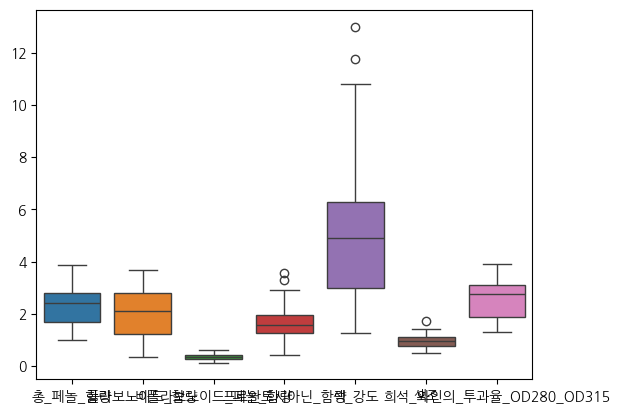

In [34]:
sns.boxplot(data.iloc[:,6:-1])

In [35]:
X = data.drop('와인_종류', axis=1)
y = data['와인_종류']

In [36]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, stratify=y, random_state=42)

In [37]:
from sklearn.preprocessing import MinMaxScaler

In [38]:
mms = MinMaxScaler()
X_train_temp = mms.fit_transform(X_train)
X_test_temp = mms.transform(X_test)
mms_X_train = pd.DataFrame(X_train_temp, columns=X_train.columns, index=X_train.index)
mms_X_test = pd.DataFrame(X_test_temp, columns=X_test.columns, index=X_test.index)

# mms 변수에 있는 MinMaxScaler 가중치 저장
# joblib
* joblib.dump(경로, 파일명)
* joblib.load(경로, 파일명)

In [39]:
import joblib

In [40]:
joblib.dump(mms, "./model/MinMax_info2.joblib")

['./model/MinMax_info2.joblib']

In [42]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
rfc = RandomForestClassifier(max_depth=3, n_estimators=500, n_jobs=-1, random_state=42)
rfc.fit(mms_X_train, y_train)
pred = rfc.predict(mms_X_test)
print(classification_report(y_test, pred))

              precision    recall  f1-score   support

           1       1.00      1.00      1.00        10
           2       1.00      0.92      0.96        13
           3       0.90      1.00      0.95         9

    accuracy                           0.97        32
   macro avg       0.97      0.97      0.97        32
weighted avg       0.97      0.97      0.97        32



In [43]:
joblib.dump(rfc, "./model/rfc_model.joblib")

['./model/rfc_model.joblib']